# 01 · Getting to know the hockey data

An introductory EDA, before cleaning aggressively or training models. We predict season **t** on the day before its first game, so season-t results are **labels only**. NHL is the provisional working scope; the final test season, ranking scope, and coach-change definition still need confirmation.

Every code cell is sandwiched between its purpose and findings. Run from the project root or notebooks folder using the project `.venv` Python interpreter. Raw CSVs are read only; reports go to `reports/eda/`.

Reference: [course supervised-learning lab](https://colab.research.google.com/drive/11yeAa7OZRws2M1o5gEPchcVVUCqIuOYd?usp=sharing). We borrow its inspection, class-balance and prediction-time feature principles. For future seasons we use chronological validation. All development seasons are inspected here, so 2009 is an illustrative backtest year, not an untouched final test.

## 1. Load the actual files

**What we want to do:** Locate all supplied CSVs, keep raw and cleaned copies separate, and establish a reproducible setup.

In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
from IPython.display import display
ROOT = Path.cwd().resolve()
if not (ROOT / 'hockey_development_data').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'hockey_development_data').is_dir(), 'Run from project root or notebooks/'
os.environ['MPLCONFIGDIR'] = str(ROOT / '.mplconfig')
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
DATA = ROOT / 'hockey_development_data'
OUT = ROOT / 'reports' / 'eda'
OUT.mkdir(parents=True, exist_ok=True)
raw = {p.stem: pd.read_csv(p) for p in sorted(DATA.glob('*.csv'))}
assert len(raw) == 22
print(f'{len(raw)} CSV tables loaded; pandas {pd.__version__}; raw data preserved.')

22 CSV tables loaded; pandas 3.0.6; raw data preserved.


**What we got:** All 22 files are CSV tables. We use pandas for inspection and preserve the original files and in-memory raw frames.

## 2. Inventory and coverage

**What we want to do:** See table sizes, inferred types, year ranges, leagues, and exact duplicates across the whole database.

In [2]:
rows=[]
for name, df in raw.items():
    rows.append(dict(table=name, rows=len(df), columns=len(df.columns),
        first_year=df['year'].min() if 'year' in df else pd.NA,
        last_year=df['year'].max() if 'year' in df else pd.NA,
        leagues=', '.join(sorted(df.lgID.dropna().unique())) if 'lgID' in df else 'no lgID column',
        duplicate_rows=int(df.duplicated().sum()), missing_pct=round(df.isna().mean().mean()*100, 1)))
inventory=pd.DataFrame(rows).set_index('table')
display(inventory)
inventory.to_csv(OUT / 'table_inventory.csv')
schema=pd.concat([pd.DataFrame({'table': name, 'column': df.columns,
    'dtype': df.dtypes.astype(str).values, 'missing_count': df.isna().sum().values,
    'missing_pct': (df.isna().mean()*100).round(2).values,
    'distinct_nonnull': df.nunique().values}) for name,df in raw.items()], ignore_index=True)
schema.to_csv(OUT / 'column_profile.csv', index=False)
display(schema[schema.table.isin(['Teams','Coaches'])])

,rows,columns,first_year,last_year,leagues,duplicate_rows,missing_pct
table,,,,,,,
AwardsCoaches,75,5,1930,2009,"NHL, WHA",0,20.0
AwardsMisc,120,6,1965,2009,NHL,0,19.7
AwardsPlayers,2021,6,1917,2009,"NHL, WHA",0,22.5
Coaches,1741,14,1909,2009,"NHA, NHL, PCHA, WCHL, WHA",0,21.0
CombinedShutouts,50,8,1929,2009,no lgID column,0,0.0
Goalies,4096,23,1909,2009,"NHA, NHL, PCHA, WCHL, WHA",0,30.8
GoaliesSC,31,11,1912,1925,"NHA, NHL, PCHA, WCHL",0,0.0
GoaliesShootout,346,8,2005,2009,no lgID column,0,0.0
HOF,356,4,1945,2009,no lgID column,0,0.0


,table,column,dtype,missing_count,missing_pct,distinct_nonnull
17,Coaches,coachID,str,0,0.00,384
18,Coaches,year,int64,0,0.00,100
19,Coaches,tmID,str,0,0.00,111
20,Coaches,lgID,str,0,0.00,5
21,Coaches,stint,int64,0,0.00,3
22,Coaches,notes,str,1730,99.37,3
23,Coaches,g,float64,1,0.06,83
24,Coaches,w,float64,1,0.06,61
25,Coaches,l,float64,1,0.06,60
26,Coaches,t,float64,1,0.06,25


**What we got:** Teams has 1,459 rows; Scoring is the largest table with 43,848 rows; Coaches has 1,741 rows. Seasonal data ends at 2009, although many specialist tables stop earlier. Five leagues occur: NHL, NHA, PCHA, WCHL, WHA. No table has exact duplicate rows. Master, HOF, and abbrev are not ordinary team-season tables; HOF.year is induction year.

## 3. Look at real rows and formats

**What we want to do:** Read actual team, coach, player, goalie and biography records rather than relying on the diagram.

In [3]:
for name in ['Teams','Coaches','Scoring','Goalies','Master']:
    print(name)
    display(raw[name].head(3))
print('Full column lists:')
for name,df in raw.items():
    print(name + ': ' + ', '.join(df.columns))
print("Teams.info():")
raw["Teams"].info()
display(raw["Teams"].describe(exclude="number"))

Teams


,year,lgID,tmID,franchID,confID,divID,rank,playoff,G,W,L,T,OTL,Pts,SoW,SoL,GF,GA,name,PIM,BenchMinor,PPG,PPC,SHA,PKG,PKC,SHF
0,1909,NHA,COB,BKN,NaN,NaN,4,NaN,12,4,8,0.0,NaN,8,NaN,NaN,79,104,Cobalt Silver Kings,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1909,NHA,HAI,MTL,NaN,NaN,5,NaN,12,4,8,0.0,NaN,8,NaN,NaN,77,83,Haileybury Hockey Club,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1909,NHA,LES,TBS,NaN,NaN,7,NaN,12,2,10,0.0,NaN,4,NaN,NaN,59,100,Les Canadiens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Coaches


,coachID,year,tmID,lgID,stint,notes,g,w,l,t,postg,postw,postl,postt
0,abelsi01c,1952,CHI,NHL,1,NaN,70.0,27.0,28.0,15.0,7.0,3.0,4.0,0.0
1,abelsi01c,1953,CHI,NHL,1,NaN,70.0,12.0,51.0,7.0,NaN,NaN,NaN,NaN
2,abelsi01c,1957,DET,NHL,2,NaN,33.0,16.0,12.0,5.0,4.0,0.0,4.0,0.0


Scoring


...

,playerID,year,stint,tmID,lgID,GP,Min,W,L,T/OL,ENG,SHO,GA,SA,PostGP,PostMin,PostW,PostL,PostT,PostENG,PostSHO,PostGA,PostSA
0,abbotge01,1943,1,BOS,NHL,1.0,60.0,0.0,1.0,0.0,NaN,0.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,abrahch01,1974,1,NEW,WHA,16.0,870.0,8.0,6.0,1.0,0.0,1.0,47.0,504.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,abrahch01,1975,1,NEW,WHA,41.0,2385.0,18.0,18.0,2.0,1.0,2.0,136.0,1221.0,1.0,1.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN


Master


,playerID,coachID,hofID,firstName,lastName,nameNote,nameGiven,nameNick,height,weight,shootCatch,legendsID,ihdbID,hrefID,firstNHL,lastNHL,firstWHA,lastWHA,pos,birthYear,birthMon,birthDay,birthCountry,birthState,birthCity,deathYear,deathMon,deathDay,deathCountry,deathState,deathCity
0,aaltoan01,NaN,NaN,Antti,Aalto,NaN,Antti,NaN,73.0,210.0,L,14862,5928.0,aaltoan01,1997.0,2000.0,NaN,NaN,C,1975.0,3.0,4.0,Finland,NaN,Lappeenranta,NaN,NaN,NaN,NaN,NaN,NaN
1,abbeybr01,NaN,NaN,Bruce,Abbey,NaN,Bruce,NaN,73.0,185.0,L,NaN,11918.0,abbeybr01,NaN,NaN,1975.0,1975.0,D,1951.0,8.0,18.0,Canada,ON,Toronto,NaN,NaN,NaN,NaN,NaN,NaN
2,abbotge01,NaN,NaN,George,Abbott,NaN,George Henry,Preacher,67.0,153.0,L,18411,14591.0,abbotge01,1943.0,1943.0,NaN,NaN,G,1911.0,8.0,3.0,Canada,ON,Synenham,NaN,NaN,NaN,NaN,NaN,NaN


Full column lists:
AwardsCoaches: coachID, award, year, lgID, note
AwardsMisc: name, ID, award, year, lgID, note
AwardsPlayers: playerID, award, year, lgID, note, pos
Coaches: coachID, year, tmID, lgID, stint, notes, g, w, l, t, postg, postw, postl, postt
CombinedShutouts: year, month, date, tmID, oppID, R/P, IDgoalie1, IDgoalie2
Goalies: playerID, year, stint, tmID, lgID, GP, Min, W, L, T/OL, ENG, SHO, GA, SA, PostGP, PostMin, PostW, PostL, PostT, PostENG, PostSHO, PostGA, PostSA
GoaliesSC: playerID, year, tmID, lgID, GP, Min, W, L, T, SHO, GA
GoaliesShootout: playerID, year, stint, tmID, W, L, SA, GA
HOF: year, hofID, name, category
Master: playerID, coachID, hofID, firstName, lastName, nameNote, nameGiven, nameNick, height, weight, shootCatch, legendsID, ihdbID, hrefID, firstNHL, lastNHL, firstWHA, lastWHA, pos, birthYear, birthMon, birthDay, birthCountry, birthState, birthCity, deathYear, deathMon, deathDay, deathCountry, deathState, deathCity
Scoring: playerID, year, stint, tmID, 

,lgID,tmID,franchID,confID,divID,playoff,name
count,1459,1459,1459,842,1111,904,1459
unique,5,114,65,4,17,24,103
top,NHL,MTL,MTL,EC,PT,CQF,Montreal Canadiens
freq,1265,92,100,231,101,128,99


**What we got:** The local columns broadly match the assignment, but capitalization and meanings matter: Teams.G is games, Scoring.G is goals, and Coaches uses lowercase g/w/l/t. Missing numeric entries lead to inferred floating-point types; IDs are categorical strings. Player and goalie rows include stints and Post* outcome columns. The info() output makes non-null counts and inferred types explicit; the categorical summary reports counts, unique values and common categories.

## 4. Conservative text cleaning

**What we want to do:** Check whitespace and placeholders before making changes. Strip outer whitespace in derived copies only; retain missing values and all records.

In [4]:
tables={}
text_changes=[]
for name,df in raw.items():
    clean=df.copy(deep=True)
    for col in clean.select_dtypes(include=['object','str']).columns:
        before=clean[col].astype('string')
        after=before.str.strip().replace('', pd.NA)
        count=int((before.fillna('<NA>') != after.fillna('<NA>')).sum())
        if count: text_changes.append({'table':name,'column':col,'changed_cells':count})
        clean[col]=after
    tables[name]=clean
text_audit=pd.DataFrame(text_changes, columns=['table','column','changed_cells'])
display(text_audit)
text_audit.to_csv(OUT / 'text_cleaning_audit.csv',index=False)
teams=tables['Teams']
nhl=teams[teams.lgID.eq('NHL')].copy()
coaches=tables['Coaches']
print('NHL team-seasons:',len(nhl))

,table,column,changed_cells


NHL team-seasons: 1265


**What we got:** Text trimming is applied only to derived frames. The audit is empty: no text cells needed trimming in these files. This leaves identifiers unchanged. NHL contributes 1,265 team-seasons. We do not fill blanks universally, remove valid co-coach records, or overwrite raw CSVs.

## 5. Grains, keys and joins

**What we want to do:** Validate the main grains and detect ambiguous keys or orphan records before combining tables.

In [5]:
key_specs={'Teams':['year','lgID','tmID'], 'TeamSplits':['year','lgID','tmID'],
    'TeamVsTeam':['year','lgID','tmID','oppID'],
    'Scoring':['playerID','year','lgID','tmID','stint'],
    'Goalies':['playerID','year','lgID','tmID','stint'],
    'Coaches':['coachID','year','lgID','tmID','stint']}
key_audit=[]
for name,key in key_specs.items():
    df=tables[name]
    key_audit.append({'table':name,'key':', '.join(key),'duplicate_keys':int(df.duplicated(key).sum()),
                      'null_key_rows':int(df[key].isna().any(axis=1).sum())})
display(pd.DataFrame(key_audit))
assert not teams.duplicated(['year','lgID','tmID']).any()
assert not nhl.duplicated(['year','lgID','franchID']).any()
join_audit=[]
for name in ['Scoring','Goalies','Coaches','TeamSplits','TeamVsTeam','TeamsPost']:
    joined=tables[name].merge(teams[['year','lgID','tmID']],on=['year','lgID','tmID'],how='left',validate='many_to_one',indicator=True)
    join_audit.append({'table':name,'unmatched_team_rows':int(joined._merge.eq('left_only').sum())})
master=tables['Master']
for name,idcol in [('Scoring','playerID'),('Goalies','playerID'),('Coaches','coachID')]:
    ids=master.loc[master[idcol].notna(),[idcol]]
    assert not ids.duplicated().any()
    join_audit.append({'table':name+' → Master','unmatched_team_rows':int((~tables[name][idcol].isin(ids[idcol])).sum())})
display(pd.DataFrame(join_audit).rename(columns={'unmatched_team_rows':'unmatched_rows'}))
pd.DataFrame(join_audit).to_csv(OUT/'join_audit.csv',index=False)
shared=coaches[coaches.duplicated(['year','lgID','tmID','stint'],keep=False)]
display(shared)
coach_totals=coaches[coaches.lgID.eq('NHL')].groupby(['year','lgID','tmID'])[['g','w','l']].sum(min_count=1).reset_index()
coach_totals=coach_totals.merge(nhl[['year','lgID','tmID','G','W','L','OTL']],on=['year','lgID','tmID'],validate='one_to_one')
display(pd.Series({f'coach {a} != team {b}':int(coach_totals[a].ne(coach_totals[b]).sum()) for a,b in [('g','G'),('w','W'),('l','L')]}))
print('Loss mismatches by year range:')
display(coach_totals[coach_totals.l.ne(coach_totals.L)].groupby('year').size())

,table,key,duplicate_keys,null_key_rows
0,Teams,"year, lgID, tmID",0,0
1,TeamSplits,"year, lgID, tmID",0,0
2,TeamVsTeam,"year, lgID, tmID, oppID",0,0
3,Scoring,"playerID, year, lgID, tmID, stint",0,0
4,Goalies,"playerID, year, lgID, tmID, stint",0,0
5,Coaches,"coachID, year, lgID, tmID, stint",0,0


,table,unmatched_rows
0,Scoring,0
1,Goalies,0
2,Coaches,0
3,TeamSplits,0
4,TeamVsTeam,0
5,TeamsPost,0
6,Scoring → Master,0
7,Goalies → Master,0
8,Coaches → Master,0


,coachID,year,tmID,lgID,stint,notes,g,w,l,t,postg,postw,postl,postt
870,lewisda01c,1998,DET,NHL,1,co-coach with Barry Smith,5.0,4.0,1.0,0.0,NaN,NaN,NaN,NaN
1516,smithba02c,1998,DET,NHL,1,co-coach with Dave Lewis,5.0,4.0,1.0,0.0,NaN,NaN,NaN,NaN


coach g != team G      1
coach w != team W      1
coach l != team L    147
dtype: int64

Loss mismatches by year range:


year
1998     1
1999    27
2000    30
2001    29
2002    30
2003    30
dtype: int64

**What we got:** All main checked keys have zero nulls/duplicates; all nine checked team/Master relationships have zero orphans. The team-season anchor and NHL franchise-season identity are unique. Two Detroit 1998 co-coaches share stint 1, but have different coachIDs; retain both. Master joins use non-null IDs only. Consult the displayed orphan counts before expanding feature joins. Coach totals differ from team totals: one games/wins mismatch and 147 losses mismatches, concentrated in 1999–2003. Do not equate coach and team loss definitions across eras or automatically repair them.

## 6. Seasons and changing competition structure

**What we want to do:** Inspect NHL team counts, games per season, missing years, and changes of team code within a franchise.

,teams,min_games,max_games,mean_points,max_rank
year,,,,,
1989,21,80,80,80.000000,6
1990,21,80,80,80.000000,6
1991,22,80,80,80.000000,6
1992,24,84,84,84.000000,6
1993,26,84,84,84.000000,7
1994,26,48,48,48.000000,7
1995,26,82,82,82.000000,7
1996,26,82,82,82.000000,7
1997,26,82,82,82.000000,7


Missing NHL years: [2004]


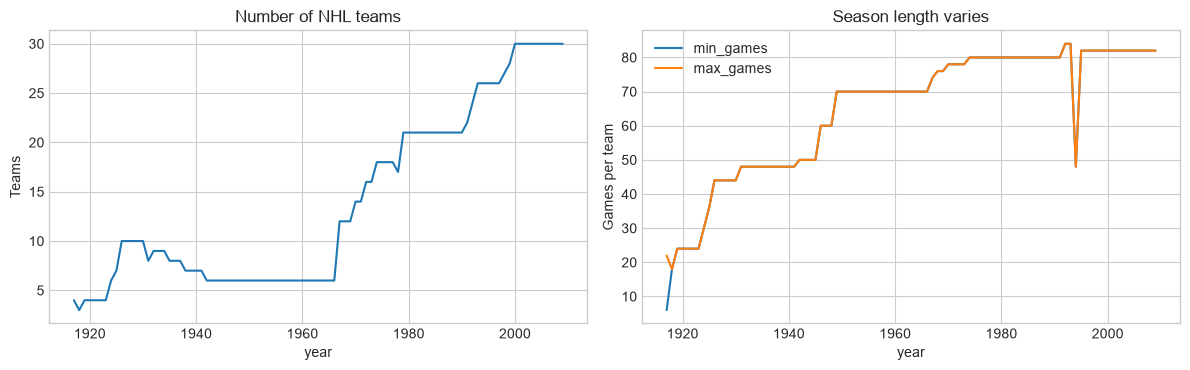

,team_codes,n_codes
franchID,,
ANA,"ANA, AND",2
BKN,"BKN, HAM, NYA, QUB",4
CAL,"ATF, CAL",2
CAR,"CAR, HAR",2
CLE,"CLE, CLF, OAK",3
COL,"COL, QUE",2
DAL,"DAL, MNS",2
DET,"DET, DTC, DTF",3
NJD,"COR, KCS, NJD",3


In [6]:
season=nhl.groupby('year').agg(teams=('tmID','size'),min_games=('G','min'),max_games=('G','max'),
    mean_points=('Pts','mean'), max_rank=('rank','max'))
display(season.tail(20))
missing_years=sorted(set(range(int(nhl.year.min()),int(nhl.year.max())+1))-set(nhl.year))
print('Missing NHL years:',missing_years)
fig,ax=plt.subplots(1,2,figsize=(12,3.8))
season.teams.plot(ax=ax[0],title='Number of NHL teams'); ax[0].set_ylabel('Teams')
season[['min_games','max_games']].plot(ax=ax[1],title='Season length varies'); ax[1].set_ylabel('Games per team')
plt.tight_layout(); plt.show()
franchise_codes=nhl.groupby('franchID').agg(team_codes=('tmID',lambda x:', '.join(sorted(x.unique()))),n_codes=('tmID','nunique'))
display(franchise_codes[franchise_codes.n_codes.gt(1)].head(15))

**What we got:** NHL year 2004 is absent; the files alone do not establish its cause. Team counts and season lengths vary, including 1994 at 48 games. Franchise IDs link changed team codes, but may be retrospective identifiers: use them to align history, not as future-information features. Exact t−1 joins will deliberately leave 2005 without 2004 inputs.

## 7. Missingness by era

**What we want to do:** Separate structural absence from unknown observations; check whether common accounting identities actually hold.

,T,OTL,SoW,SoL,PPC,PKC,BenchMinor,confID,divID,playoff
era,,,,,,,,,,
1917–1966,0.0,100.0,100.0,100.0,92.7,92.7,100.0,100.0,66.7,34.3
1967–1998,0.0,100.0,100.0,100.0,0.0,0.0,3.8,15.0,0.0,31.9
1999–2004,0.0,0.0,100.0,100.0,0.0,0.0,0.0,0.0,0.0,45.9
2005–2009,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46.7


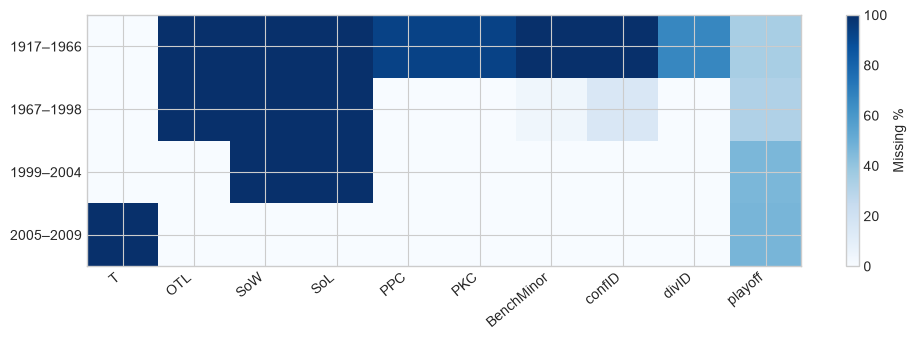

modern missing OTL        0
modern missing T        150
modern G != W+L+OTL       0
modern Pts != 2W+OTL      0
dtype: int64

Playoff values (including blank): {<NA>: 454, 'CQF': 128, 'SF': 112, 'DSF': 96, 'SC': 90, 'QF': 88, 'F': 84, 'CSF': 64, 'CF': 56, 'DF': 48, 'PRE': 36, 'NHLF': 8, 'ND': 1}


In [7]:
nhl['era']=pd.cut(nhl.year,[1916,1966,1998,2004,2009],labels=['1917–1966','1967–1998','1999–2004','2005–2009'])
fields=['T','OTL','SoW','SoL','PPC','PKC','BenchMinor','confID','divID','playoff']
era_missing=nhl.groupby('era',observed=True)[fields].agg(lambda x:round(x.isna().mean()*100,1))
display(era_missing)
fig,ax=plt.subplots(figsize=(10,3.5))
im=ax.imshow(era_missing.to_numpy(),aspect='auto',vmin=0,vmax=100,cmap='Blues')
ax.set_xticks(range(len(fields)),fields,rotation=40,ha='right'); ax.set_yticks(range(len(era_missing)),era_missing.index)
fig.colorbar(im,ax=ax,label='Missing %'); plt.tight_layout(); plt.show()
# Era-restricted checks, not blanket imputation.
modern=nhl[nhl.year.ge(2005)].copy()
checks=pd.Series({'modern missing OTL':int(modern.OTL.isna().sum()),
    'modern missing T':int(modern['T'].isna().sum()),
    'modern G != W+L+OTL':int((modern.G != modern.W+modern.L+modern.OTL).sum()),
    'modern Pts != 2W+OTL':int((modern.Pts != 2*modern.W+modern.OTL).sum())})
display(checks)
print('Playoff values (including blank):',nhl.playoff.value_counts(dropna=False).to_dict())

**What we got:** Missingness follows eras: ties are blank in 2005–2009, while shootout fields appear from 2005. For all 150 modern team-seasons, OTL is complete and both games and points identities hold. A blank playoff entry cannot be treated as an ordinary missing number; it may encode non-qualification. Avoid blanket zero filling; use documented era-specific derived calculations later.

## 8. What does rank mean?

**What we want to do:** Compare stored rankings with points in the latest season and construct a transparent exploratory league-wide points rank.

In [8]:
LATEST=int(nhl.year.max())
latest=nhl[nhl.year.eq(LATEST)].copy()
latest['points_rank_tied']=latest.Pts.rank(ascending=False,method='min').astype(int)
display(latest[['name','tmID','confID','divID','rank','Pts','points_rank_tied']].sort_values(['Pts','name'],ascending=[False,True]))
display(latest.groupby(['confID','divID']).agg(teams=('tmID','size'),min_rank=('rank','min'),max_rank=('rank','max')))
print('Teams participating in tied points groups:',int(latest.Pts.duplicated(keep=False).sum()))

,name,tmID,confID,divID,rank,Pts,points_rank_tied
1458,Washington Capitals,WAS,EC,SE,1,121,1
1453,San Jose Sharks,SJS,WC,PC,1,113,2
1436,Chicago Blackhawks,CHI,WC,CE,1,112,3
1451,Phoenix Coyotes,PHO,WC,PC,2,107,4
1446,New Jersey Devils,NJD,EC,AT,1,103,5
1457,Vancouver Canucks,VAN,WC,NW,1,103,5
1439,Detroit Red Wings,DET,WC,CE,2,102,7
1442,Los Angeles Kings,LAK,WC,PC,3,101,8
1452,Pittsburgh Penguins,PIT,EC,AT,2,101,8
1432,Buffalo Sabres,BUF,EC,NE,1,100,10


teams  min_rank  max_rank
confID divID                           
EC     AT         5         1         5
       NE         5         1         5
       SE         5         1         5
WC     CE         5         1         5
       NW         5         1         5
       PC         5         1         5

Teams participating in tied points groups: 15


**What we got:** In 2009 each of six divisions has ranks 1–5. Stored rank is therefore division-scoped in this season. Points rank is a useful exploratory label, but tied teams share ranks and official tie-breakers are not implemented. Predicting Pts or Pts/G then sorting is a candidate regression approach, pending the required ranking scope.

## 9. Simple team performance EDA

**What we want to do:** Explore points, points per game and goal difference per game, and distinguish same-season associations from predictive evidence.

,G,W,Pts,points_per_game,goal_diff_per_game
count,1265.000,1265.000,1265.000,1265.000,1265.000
mean,72.870,31.906,74.509,1.020,-0.002
std,14.821,10.923,23.055,0.232,0.755
min,6.000,1.000,2.000,0.262,-3.583
25%,70.000,24.000,58.000,0.862,-0.439
50%,80.000,32.000,77.000,1.038,0.024
75%,82.000,40.000,92.000,1.175,0.461
max,84.000,62.000,132.000,1.750,2.700


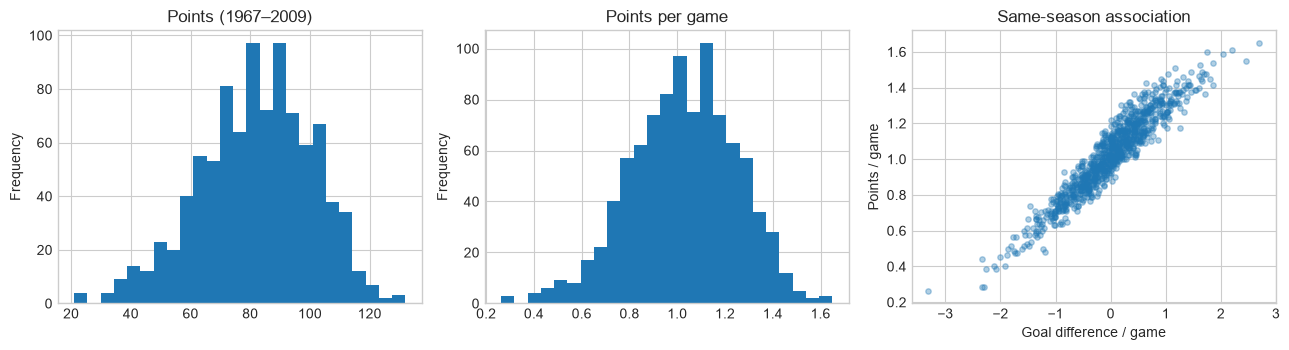

,Pts,points_per_game,goal_diff_per_game,goals_for_per_game,goals_against_per_game
Pts,1.000,0.952,0.888,0.421,-0.616
points_per_game,0.952,1.000,0.947,0.457,-0.649
goal_diff_per_game,0.888,0.947,1.000,0.560,-0.611
goals_for_per_game,0.421,0.457,0.560,1.000,0.313
goals_against_per_game,-0.616,-0.649,-0.611,0.313,1.000


In [9]:
nhl['points_per_game']=nhl.Pts / nhl.G
nhl['goal_diff_per_game']=(nhl.GF-nhl.GA) / nhl.G
nhl['goals_for_per_game']=nhl.GF/nhl.G
nhl['goals_against_per_game']=nhl.GA/nhl.G
display(nhl[['G','W','Pts','points_per_game','goal_diff_per_game']].describe().round(3))
recent=nhl[nhl.year.ge(1967)]
fig,ax=plt.subplots(1,3,figsize=(13,3.6))
recent.Pts.plot.hist(bins=25,ax=ax[0],title='Points (1967–2009)')
recent.points_per_game.plot.hist(bins=25,ax=ax[1],title='Points per game')
ax[2].scatter(recent.goal_diff_per_game,recent.points_per_game,alpha=.35,s=15)
ax[2].set(xlabel='Goal difference / game',ylabel='Points / game',title='Same-season association')
plt.tight_layout(); plt.show()
display(recent[['Pts','points_per_game','goal_diff_per_game','goals_for_per_game','goals_against_per_game']].corr().round(3))

**What we got:** Normalizing by games helps compare season lengths, but it does not remove scoring-rule changes. Same-season goal difference is associated with points and is useful for understanding performance. It would leak the target season if used directly to predict that season; only lagged versions belong in preseason features.

## 10. Define coach-change candidates

**What we want to do:** Use ordered appointments for in-season changes, show co-coaching explicitly, and build a separate offseason turnover candidate.

In [10]:
cn=coaches[coaches.lgID.eq('NHL')].copy()
coach_summary=cn.groupby(['year','lgID','tmID']).agg(coach_rows=('coachID','size'),
    distinct_coaches=('coachID','nunique'),distinct_stints=('stint','nunique'),
    min_stint=('stint','min'),max_stint=('stint','max'),missing_stint=('stint',lambda s:s.isna().any())).reset_index()
# Multiple distinct stints are a proxy for appointment changes, not necessarily firings.
coach_summary['inseason_change_proxy']=coach_summary.distinct_stints.gt(1).astype('Int64')
coach_summary.loc[coach_summary.missing_stint,'inseason_change_proxy']=pd.NA
labels=nhl.merge(coach_summary,on=['year','lgID','tmID'],how='left',validate='one_to_one')
print('Team-seasons without coach coverage:',int(labels.coach_rows.isna().sum()))
display(labels.inseason_change_proxy.value_counts(dropna=False).rename('team_seasons'))
display(coach_summary[coach_summary.distinct_stints.gt(1)].tail(10))
# A shared stint is a set of coaches, not one arbitrary row.
cn=cn.merge(nhl[['year','lgID','tmID','franchID']],on=['year','lgID','tmID'],how='inner',validate='many_to_one')
appointments=[]
for (year,league,franchise),g in cn.groupby(['year','lgID','franchID']):
    if g.stint.isna().any(): continue
    appointments.append({'year':year,'lgID':league,'franchID':franchise,
        'start_coaches':tuple(sorted(g.loc[g.stint.eq(g.stint.min()),'coachID'].unique())),
        'end_coaches':tuple(sorted(g.loc[g.stint.eq(g.stint.max()),'coachID'].unique()))})
appointments=pd.DataFrame(appointments)
previous=appointments[['year','lgID','franchID','end_coaches']].copy()
previous['year']+=1
previous=previous.rename(columns={'end_coaches':'prior_end_coaches'})
turnover=appointments.merge(previous,on=['year','lgID','franchID'],how='left',validate='one_to_one')
turnover['offseason_change_proxy']=pd.Series(pd.NA,index=turnover.index,dtype='Int64')
known=turnover.prior_end_coaches.notna()
turnover.loc[known,'offseason_change_proxy']=(turnover.loc[known,'start_coaches'] != turnover.loc[known,'prior_end_coaches']).astype(int)
display(turnover[['year','franchID','start_coaches','prior_end_coaches','offseason_change_proxy']].tail(10))
labels=labels.merge(turnover[['year','lgID','franchID','offseason_change_proxy']],on=['year','lgID','franchID'],how='left',validate='one_to_one')
labels[['year','lgID','tmID','franchID','distinct_coaches','distinct_stints','inseason_change_proxy','offseason_change_proxy']].to_csv(OUT/'coach_target_candidates.csv',index=False)

Team-seasons without coach coverage: 0


inseason_change_proxy
0    1040
1     225
Name: team_seasons, dtype: Int64

,year,lgID,tmID,coach_rows,distinct_coaches,distinct_stints,min_stint,max_stint,missing_stint,inseason_change_proxy
1210,2008,NHL,CAR,2,2,2,1,2,False,1
1212,2008,NHL,CHI,2,2,2,1,2,False,1
1220,2008,NHL,MTL,2,2,2,1,2,False,1
1224,2008,NHL,NYR,2,2,2,1,2,False,1
1225,2008,NHL,OTT,2,2,2,1,2,False,1
1228,2008,NHL,PIT,2,2,2,1,2,False,1
1231,2008,NHL,TBL,2,2,2,1,2,False,1
1241,2009,NHL,CBS,2,2,2,1,2,False,1
1256,2009,NHL,PHI,2,2,2,1,2,False,1
1260,2009,NHL,STL,2,2,2,1,2,False,1


,year,franchID,start_coaches,prior_end_coaches,offseason_change_proxy
1255,2009,PHI,"(stevejo01c,)","(stevejo01c,)",0
1256,2009,PHO,"(gretzwa01c,)","(gretzwa01c,)",0
1257,2009,PIT,"(bylsmda01c,)","(bylsmda01c,)",0
1258,2009,SJS,"(mclelto01c,)","(mclelto01c,)",0
1259,2009,STL,"(murraan01c,)","(murraan01c,)",0
1260,2009,TBL,"(tocchri01c,)","(tocchri01c,)",0
1261,2009,TOR,"(wilsoro02c,)","(wilsoro02c,)",0
1262,2009,VAN,"(vigneal01c,)","(vigneal01c,)",0
1263,2009,WAS,"(boudrbr01c,)","(boudrbr01c,)",0
1264,2009,WPG,"(anderjo01c,)","(anderjo01c,)",0


**What we got:** Two different labels are available: multiple ordered stints during a season, and a different first coach set from the previous season’s final set. Neither label proves a firing; temporary appointments and returns can count. Co-coaches in the same stint are not an in-season change by themselves. Offseason turnover may already be known at the prediction cutoff, so its role needs assignment clarification. Missing coverage stays unknown. All 1,265 NHL team-seasons have coach coverage; 225 have multiple distinct stints.

## 11. Coach class balance over time

**What we want to do:** Measure the in-season proxy prevalence and its relationship to prior-season performance without suggesting causation.

,team_seasons,known,changed,change_rate
year,,,,
1994,26,26,3,0.115385
1995,26,26,7,0.269231
1996,26,26,3,0.115385
1997,26,26,6,0.230769
1998,27,27,4,0.148148
1999,28,28,4,0.142857
2000,30,30,8,0.266667
2001,30,30,5,0.166667
2002,30,30,8,0.266667


Known-label prevalence: 0.1779


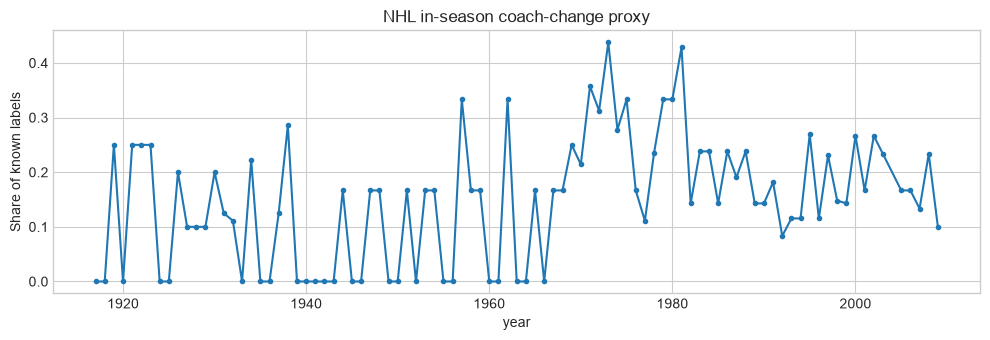

Majority/minority ratio: 4.62
Always-no-change descriptive accuracy: 0.8221


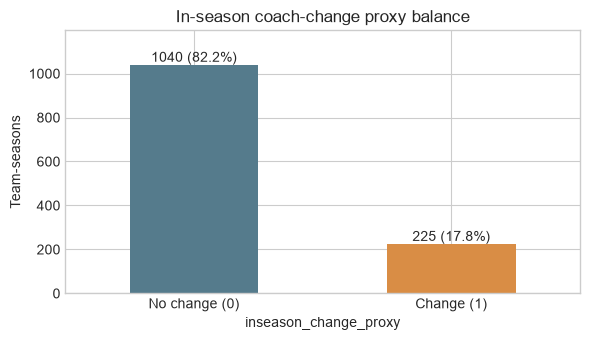

In [11]:
coach_rates=labels.groupby('year').agg(team_seasons=('tmID','size'),known=('inseason_change_proxy','count'),
    changed=('inseason_change_proxy','sum'),change_rate=('inseason_change_proxy','mean'))
display(coach_rates.tail(15))
print('Known-label prevalence:',round(float(labels.inseason_change_proxy.mean()),4))
fig,ax=plt.subplots(figsize=(10,3.5))
coach_rates.change_rate.plot(ax=ax,marker='.',title='NHL in-season coach-change proxy')
ax.set_ylabel('Share of known labels'); plt.tight_layout(); plt.show()
counts=labels.inseason_change_proxy.value_counts().reindex([0,1],fill_value=0)
print('Majority/minority ratio:',round(float(counts.max()/counts.min()),2))
print('Always-no-change descriptive accuracy:',round(float(counts[0]/counts.sum()),4))
fig,ax=plt.subplots(figsize=(6,3.5))
counts.plot.bar(ax=ax,color=['#557B8C','#D98D45'],rot=0)
ax.set(xticklabels=['No change (0)','Change (1)'],ylabel='Team-seasons',title='In-season coach-change proxy balance')
for i,value in enumerate(counts): ax.text(i,value,f'{value} ({value/counts.sum():.1%})',ha='center',va='bottom')
ax.set_ylim(0,counts.max()*1.15); plt.tight_layout(); plt.show()


**What we got:** 225 of 1,265 NHL team-seasons (17.79%) have the in-season change proxy; 1,040 (82.21%) do not. The majority/minority ratio is 4.62. Always predicting no change would achieve 82.21% descriptive accuracy while detecting zero changes, illustrating why recall and precision matter. This is not a held-out baseline score. Yearly rates vary; the definition remains provisional.

## 12. Build a leakage-safe historical example

**What we want to do:** Align previous-year team performance with target-season labels by franchise and league, using an exact year join.

In [12]:
feature_cols=['G','W','Pts','points_per_game','goal_diff_per_game','goals_for_per_game','goals_against_per_game']
prior=nhl[['year','lgID','franchID']+feature_cols].copy()
prior['feature_year']=prior.year
prior['year']+=1
prior=prior.rename(columns={c:'prev_'+c for c in feature_cols})
learning=labels[['year','lgID','tmID','franchID','name','Pts','points_per_game','rank','inseason_change_proxy']].merge(
    prior,on=['year','lgID','franchID'],how='left',validate='one_to_one')
learning=learning.rename(columns={'Pts':'target_points','points_per_game':'target_points_per_game','rank':'target_stored_rank'})
learning['target_points_rank_tied']=learning.groupby(['year','lgID']).target_points.rank(ascending=False,method='min')
matched=learning.feature_year.notna()
assert (learning.loc[matched,'feature_year'] == learning.loc[matched,'year']-1).all()
assert learning[learning.year.eq(2005)].feature_year.isna().all()
print('All team-seasons:',len(learning),'with exact prior-year features:',int(matched.sum()),'without:',int((~matched).sum()))
display(learning[learning.year.eq(LATEST)].head(10))
eligible=learning[matched & learning.inseason_change_proxy.notna()].copy()
print('Historical illustration only:', 'train years <',LATEST,'=',int(eligible.year.lt(LATEST).sum()),
    '; holdout year',LATEST,'=',int(eligible.year.eq(LATEST).sum()))
display(eligible[['target_points_per_game','prev_points_per_game','prev_goal_diff_per_game']].corr().round(3))
display(eligible.groupby('inseason_change_proxy').agg(n=('tmID','size'),mean_prev_ppg=('prev_points_per_game','mean')))
learning.to_csv(OUT/'team_season_learning_preview.csv',index=False)
FEATURES=['prev_'+c for c in feature_cols]
X_preview=eligible[FEATURES].copy()
y_regression_preview=eligible['target_points_per_game'].copy()
y_classification_preview=eligible['inseason_change_proxy'].copy()
assert all(c.startswith('prev_') for c in X_preview.columns)
print('Candidate X columns:',FEATURES)
print('Regression target: target_points_per_game; classification target: inseason_change_proxy')


All team-seasons: 1265 with exact prior-year features: 1198 without: 67


,year,lgID,tmID,franchID,name,target_points,target_points_per_game,target_stored_rank,inseason_change_proxy,prev_G,prev_W,prev_Pts,prev_points_per_game,prev_goal_diff_per_game,prev_goals_for_per_game,prev_goals_against_per_game,feature_year,target_points_rank_tied
1235,2009,NHL,AND,ANA,Anaheim Ducks,89,1.085366,4,0,82.0,42.0,91.0,1.109756,0.085366,2.987805,2.902439,2008.0,17.0
1236,2009,NHL,ATL,WPG,Atlanta Thrashers,83,1.012195,2,0,82.0,35.0,76.0,0.926829,-0.280488,3.134146,3.414634,2008.0,23.0
1237,2009,NHL,BOS,BOS,Boston Bruins,91,1.109756,3,0,82.0,53.0,116.0,1.414634,0.951220,3.341463,2.390244,2008.0,14.0
1238,2009,NHL,BUF,BUF,Buffalo Sabres,100,1.219512,1,0,82.0,41.0,91.0,1.109756,0.195122,3.048780,2.853659,2008.0,10.0
1239,2009,NHL,CAL,CAL,Calgary Flames,90,1.097561,3,0,82.0,46.0,98.0,1.195122,0.073171,3.097561,3.024390,2008.0,15.0
1240,2009,NHL,CAR,CAR,Carolina Hurricanes,80,0.975610,3,0,82.0,45.0,97.0,1.182927,0.158537,2.914634,2.756098,2008.0,24.0
1241,2009,NHL,CBS,CBS,Columbus Blue Jackets,79,0.963415,5,1,82.0,41.0,92.0,1.121951,-0.048780,2.756098,2.804878,2008.0,26.0
1242,2009,NHL,CHI,CHI,Chicago Blackhawks,112,1.365854,1,0,82.0,46.0,104.0,1.268293,0.585366,3.219512,2.634146,2008.0,3.0
1243,2009,NHL,COL,COL,Colorado Avalanche,95,1.158537,2,0,82.0,32.0,69.0,0.841463,-0.707317,2.426829,3.134146,2008.0,12.0
1244,2009,NHL,DAL,DAL,Dallas Stars,88,1.073171,5,0,82.0,36.0,83.0,1.012195,-0.329268,2.804878,3.134146,2008.0,18.0


Historical illustration only: train years < 2009 = 1168 ; holdout year 2009 = 30


,target_points_per_game,prev_points_per_game,prev_goal_diff_per_game
target_points_per_game,1.000,0.636,0.637
prev_points_per_game,0.636,1.000,0.946
prev_goal_diff_per_game,0.637,0.946,1.000


,n,mean_prev_ppg
inseason_change_proxy,,
0,984,1.033464
1,214,0.951583


Candidate X columns: ['prev_G', 'prev_W', 'prev_Pts', 'prev_points_per_game', 'prev_goal_diff_per_game', 'prev_goals_for_per_game', 'prev_goals_against_per_game']
Regression target: target_points_per_game; classification target: inseason_change_proxy


**What we got:** Each feature comes from exactly t−1; target-season outcomes are named target_* and must be excluded from X. Year 2005 has no 2004 history, rather than silently borrowing 2003. New entrants also lack a full lag. This is an illustrative table, not a final training dataset; actual target-season membership, roster knowledge, target definition and era selection still need confirmation. A holdout at 2009 is historical only, not the assigned final test. Exact prior-year features exist for 1,198 rows; 67 are unmatched. The pooled lagged points/game correlation is 0.636, but era mixing may affect it. Explicit X_preview columns whitelist only prev_* values, and the two y vectors remain provisional.

## Cleaning decisions and next step

**Apply now:** trim outer text whitespace in copies; preserve IDs and raw files; validate joins; normalize performance by games for exploration; retain co-coaches; leave missing labels unknown; use exact calendar-year franchise lags.

**Defer:** era-aware numerical imputation, playoff blank semantics, player/goalie stint aggregation, historical roster reconstruction, scaling and feature selection. Never replace all missing values with zero. Fit any learned preprocessing only on training seasons.

**Before modeling:** confirm test year and league, ranking scope/tie handling, and in-season versus offseason coach changes. Select a relevant historical era, build chronological backtests, and compare against simple prior-season ranking and prevalence baselines. Task (c) remains TBA.

See `docs/data.md` for the reference and `docs/memory.md` for current status. Reports are reproducible outputs of this notebook, not modified source data.